In [1]:
import numpy as np

# Ch6_Q8
<h3>In this exercise, we will generate simulated data, and will then use this data to perform forward and backward stepwise selection.

### (a) Create a random number generator and use its normal() method to generate a predictor X of length n = 100, as well as a noise vector $\varepsilon$ of length n = 100.

In [2]:
rng = np.random.default_rng(1)
X = rng.normal(size=100)
epsilon = rng.normal(size=100)

### **(b)** Generate a response vector $Y$ of length $n = 100$ according to the model  
$
Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \beta_3 X^3 + \varepsilon,
$
where $\beta_0$, $\beta_1$, $\beta_2$, and $\beta_3$ are constants of your choice.

In [3]:
beta_0 = 1
beta_1 = 2
beta_2 = -3
beta_3 = 2

Y = beta_0 + beta_1*X + beta_2*(X**2) + beta_3*(X**3) + epsilon

### (c) Use forward stepwise selection in order to select a model containing the predictors $X, X^2, \ldots, X^{10}$. What is the model obtained according to $C_p$? Report the coefficients of the model obtained.

In [ ]:
import pandas as pd
import statsmodels.api as sm

data = pd.DataFrame({"X": X})
for p in range(2, 11):
    data[f"X{p}"] = X**p


X_full = sm.add_constant(data)
full_model = sm.OLS(Y, X_full).fit()
sigma2_hat = full_model.mse_resid 

print("Estimated sigma^2 from full model:", sigma2_hat)


candidate_vars = list(data.columns) 
selected_vars = []
results_step = [] 
current_vars = [] 

for k in range(1, len(candidate_vars) + 1):
    best_cp = np.inf
    best_var = None
    best_model = None
    
    for v in candidate_vars:
        if v in current_vars:
            continue
        
        trial_vars = current_vars + [v]
        X_trial = sm.add_constant(data[trial_vars])
        model_trial = sm.OLS(Y, X_trial).fit()
        
        rss = np.sum(model_trial.resid**2)
        d = len(model_trial.params)
        
        cp = rss / sigma2_hat - (n - 2*d)
        
        if cp < best_cp:
            best_cp = cp
            best_var = v
            best_model = model_trial
    
    current_vars.append(best_var)
    results_step.append({
        "k": len(current_vars),
        "vars": current_vars.copy(),
        "Cp": best_cp,
        "model": best_model
    })

cp_values = [r["Cp"] for r in results_step]
best_index = int(np.argmin(cp_values))
best_result = results_step[best_index]

print("=== Best model according to Cp ===")
print("Number of predictors (k):", best_result["k"])
print("Selected variables:", best_result["vars"])
print("Cp:", best_result["Cp"])

print("Coefficients of the selected model:")
print(best_model.params)

Estimated sigma^2 from full model: 0.9382306491875373
=== Best model according to Cp ===
Number of predictors (k): 4
Selected variables: ['X3', 'X2', 'X', 'X10']
Cp: 2.9076014725546173
Coefficients of the selected model:
const    1.013911
X3       3.628934
X2      -3.546296
X        1.666837
X10     -0.035270
X4       1.307437
X5      -2.056561
X8       0.366501
X9      -0.081287
X7       0.751092
X6      -1.212420
dtype: float64


### (d) Repeat (c), using backwards stepwise selection. How does your answer compare to the results in (c)?

In [9]:
X_full = sm.add_constant(data)
full_model = sm.OLS(Y, X_full).fit()
sigma2_hat = full_model.mse_resid
n = len(Y)

remaining_vars = list(data.columns)
results_backward = []

for k in range(len(remaining_vars), 0, -1):

    best_cp = np.inf
    best_model = None
    best_vars = None


    for v in remaining_vars:
        trial = [x for x in remaining_vars if x != v]

        X_trial = sm.add_constant(data[trial])
        model_trial = sm.OLS(Y, X_trial).fit()

        rss = np.sum(model_trial.resid**2)
        d = len(model_trial.params)

        cp = rss / sigma2_hat - (n - 2*d)

        if cp < best_cp:
            best_cp = cp
            best_model = model_trial
            best_vars = trial


    results_backward.append({
        "k": len(best_vars),
        "vars": best_vars,
        "Cp": best_cp,
        "model": best_model
    })

    remaining_vars = best_vars


cp_values = [r["Cp"] for r in results_backward]
best_index = int(np.argmin(cp_values))
best_backward = results_backward[best_index]

print("=== Best Backward Stepwise Model ===")
print("Number of predictors:", best_backward["k"])
print("Selected variables:", best_backward["vars"])
print("Cp:", best_backward["Cp"])
print(best_backward["model"].params)

=== Best Backward Stepwise Model ===
Number of predictors: 4
Selected variables: ['X', 'X2', 'X3', 'X8']
Cp: 3.670560540008026
const    1.068365
X        1.784801
X2      -3.286965
X3       2.102171
X8       0.001991
dtype: float64


Forward selection selected the predictors:'X3', 'X2', 'X', 'X10'
Backward selection selected the predictors:'X', 'X2', 'X3', 'X8'

two methods contain x,x^2,x^3. they are real predictors. others predictors like x^4,...,x^10 are removed because they do not improve the model performance.

### **(e)** Now fit a lasso model to the simulated data, again using $X, X^2, \ldots, X^{10}$ as predictors. Use cross-validation to select the optimal value of $\lambda$. Create plots of the cross-validation error as a function of $\lambda$. Report the resulting coefficient estimates, and discuss the results obtained.

In [10]:
predictors = data.values
Y_vec = Y

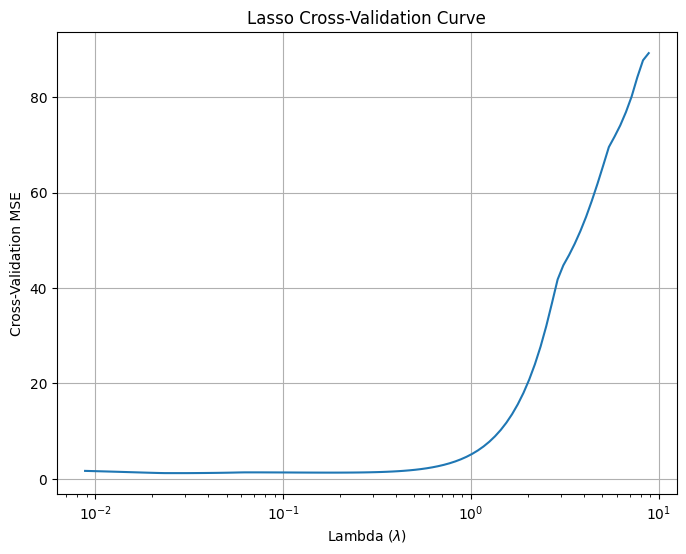

In [11]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

scaler = StandardScaler()
X_scaled = scaler.fit_transform(predictors)

lasso_cv = LassoCV(cv=10, random_state=123)
lasso_cv.fit(X_scaled, Y_vec)

plt.figure(figsize=(8, 6))
plt.plot(lasso_cv.alphas_, lasso_cv.mse_path_.mean(axis=1))
plt.xscale("log")
plt.xlabel(r"Lambda ($\lambda$)")
plt.ylabel("Cross-Validation MSE")
plt.title("Lasso Cross-Validation Curve")
plt.grid(True)
plt.show()

In [12]:
lasso_coef_scaled = lasso_cv.coef_
lasso_coef_raw = lasso_coef_scaled / scaler.scale_

coef_table = pd.Series(lasso_coef_raw, index=data.columns)
print("=== LASSO Coefficients (unscaled) ===")
print(coef_table)
print("\nIntercept:", lasso_cv.intercept_)
print("Best lambda (alpha):", lasso_cv.alpha_)

=== LASSO Coefficients (unscaled) ===
X      1.857091
X2    -3.166086
X3     2.057114
X4    -0.000000
X5     0.000000
X6     0.000000
X7    -0.000000
X8     0.000000
X9    -0.000000
X10    0.000189
dtype: float64

Intercept: -2.2314134099090106
Best lambda (alpha): 0.028913794132360563


we fit a lasso model with 10-fold cross-validation to select the optimal value of the tuning parameter $\lambda$. from x^4 to x^10 cofficient are 0, non-zero cof are x, x^2 and x^3 they are real predictor and important to the model.

### **(f)** Now generate a response vector $Y$ according to the model  
$
Y = \beta_0 + \beta_7 X^7 + \varepsilon,
$
and perform forward stepwise selection and the lasso. Discuss the results obtained.

In [13]:
rng = np.random.default_rng(2)
X = rng.normal(size=100)
epsilon = rng.normal(size=100)

beta_0 = 1
beta_7 = 2

Y = beta_0 + beta_7 * (X**7) + epsilon

In [14]:
data = pd.DataFrame({"X": X})
for p in range(2, 11):
    data[f"X{p}"] = X**p

In [15]:
# forward
n = len(Y)

X_full = sm.add_constant(data)
full_model = sm.OLS(Y, X_full).fit()
sigma2_hat = full_model.mse_resid

candidate_vars = list(data.columns)
current_vars = []
results_forward = []

for k in range(1, len(candidate_vars) + 1):
    best_cp = np.inf
    best_var = None
    best_model = None
    
    for v in candidate_vars:
        if v in current_vars:
            continue
        trial_vars = current_vars + [v]
        X_trial = sm.add_constant(data[trial_vars])
        model_trial = sm.OLS(Y, X_trial).fit()
        
        rss = np.sum(model_trial.resid**2)
        d = len(model_trial.params)
        cp = rss / sigma2_hat - (n - 2*d)
        
        if cp < best_cp:
            best_cp = cp
            best_var = v
            best_model = model_trial
    
    current_vars.append(best_var)
    results_forward.append({
        "k": len(current_vars),
        "vars": current_vars.copy(),
        "Cp": best_cp,
        "model": best_model
    })

cp_values = [r["Cp"] for r in results_forward]
best_idx = int(np.argmin(cp_values))
best_forward = results_forward[best_idx]

print("Best forward stepwise model (Cp):")
print("k =", best_forward["k"])
print("vars =", best_forward["vars"])
print("Cp =", best_forward["Cp"])
print("coefficients:")
print(best_forward["model"].params)

Best forward stepwise model (Cp):
k = 2
vars = ['X7', 'X']
Cp = 4.173861840957045
coefficients:
const    0.984463
X7       1.997575
X        0.232915
dtype: float64


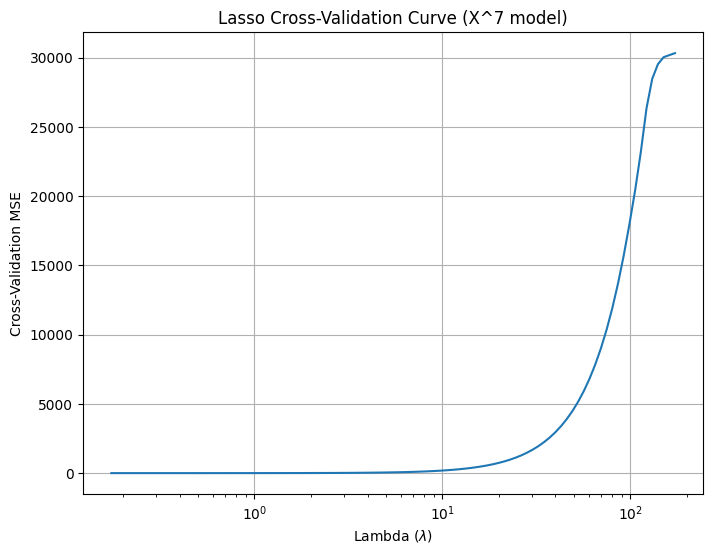

Best lambda: 0.18548133253102123
LASSO coefficients (unscaled):
X     -0.154108
X2     0.000000
X3     0.000000
X4     0.050652
X5     1.678373
X6     0.000000
X7     1.205951
X8     0.000000
X9     0.086483
X10    0.000000
dtype: float64
Intercept: -7.557875004396217


In [16]:
# LASSO
X_mat = data.values
Y_vec = Y 

# 標準化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_mat)

lasso_cv = LassoCV(cv=10, random_state=123)
lasso_cv.fit(X_scaled, Y_vec)

# CV 曲線
plt.figure(figsize=(8, 6))
plt.plot(lasso_cv.alphas_, lasso_cv.mse_path_.mean(axis=1))
plt.xscale("log")
plt.xlabel(r"Lambda ($\lambda$)")
plt.ylabel("Cross-Validation MSE")
plt.title("Lasso Cross-Validation Curve (X^7 model)")
plt.grid(True)
plt.show()

# 反標準化係數
coef_scaled = lasso_cv.coef_
coef_raw = coef_scaled / scaler.scale_
coef_table = pd.Series(coef_raw, index=data.columns)

print("Best lambda:", lasso_cv.alpha_)
print("LASSO coefficients (unscaled):")
print(coef_table)
print("Intercept:", lasso_cv.intercept_)


forward selection: x,x^7
LASSO: x, x^5, x^7, x^9

they are both selecting x^7, and the largest coefficient is associated with x^7. because exist highly correlated predictors forward select x and LASSO select x,x^5 and x^9

# Ch6_Q9(abcde)
<h3>In this exercise, we will predict the number of applications received using the other variables in the College data set.

In [25]:
import pandas as pd

college = pd.read_csv("college.csv")
college.head()

,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [26]:
college['Private'] = college['Private'].map({'Yes':1, 'No':0})

In [29]:
college = college.drop(columns=['Unnamed: 0'])

In [30]:
college

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,1,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,1,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,1,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,1,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,1,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,0,2197,1515,543,4,26,3089,2029,6797,3900,500,1200,60,60,21.0,14,4469,40
773,1,1959,1805,695,24,47,2849,1107,11520,4960,600,1250,73,75,13.3,31,9189,83
774,1,2097,1915,695,34,61,2793,166,6900,4200,617,781,67,75,14.4,20,8323,49
775,1,10705,2453,1317,95,99,5217,83,19840,6510,630,2115,96,96,5.8,49,40386,99


### **(a)** Split the data set into a training set and a test set.

In [31]:
train = college.sample(frac=0.7, random_state=1)
test = college.drop(train.index)

### **(b)** Fit a linear model using least squares on the training set, and report the test error obtained.


In [32]:
x_train = train.drop(columns=["Apps"])
y_train = train["Apps"]

x_test = test.drop(columns=["Apps"])
y_test = test["Apps"]


X_train_sm = sm.add_constant(x_train)
X_test_sm = sm.add_constant(x_test)

ols_model = sm.OLS(y_train, X_train_sm).fit()

y_pred = ols_model.predict(X_test_sm)

test_mse = np.mean((y_test - y_pred)**2)

print("Test MSE:", test_mse)
print(ols_model.summary())

Test MSE: 1294832.8276813806
                            OLS Regression Results                            
Dep. Variable:                   Apps   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.934
Method:                 Least Squares   F-statistic:                     451.6
Date:                Thu, 20 Nov 2025   Prob (F-statistic):          1.21e-300
Time:                        23:23:42   Log-Likelihood:                -4533.5
No. Observations:                 544   AIC:                             9103.
Df Residuals:                     526   BIC:                             9180.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        -857.866

### **(c)** Fit a ridge regression model on the training set, with $\lambda$ chosen by cross-validation. Report the test error obtained.

In [33]:
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import numpy as np

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

lambdas = np.logspace(-3, 5, 200)


ridge_cv = RidgeCV(alphas=lambdas, scoring="neg_mean_squared_error", cv=10)
ridge_cv.fit(X_train_scaled, y_train)


best_lambda = ridge_cv.alpha_
print("Best λ =", best_lambda)

Best λ = 0.001


In [34]:
y_pred = ridge_cv.predict(X_test_scaled)

test_mse_ridge = mean_squared_error(y_test, y_pred)

print("Test MSE (Ridge):", test_mse_ridge)

Test MSE (Ridge): 1294811.0790720053


### **(d)** Fit a lasso model on the training set, with $\lambda$ chosen by cross-validation. Report the test error obtained, along with the number of non-zero coefficient estimates.

In [35]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

# LASSO with cross-validation
lasso_cv = LassoCV(cv=10, random_state=1)
lasso_cv.fit(X_train_scaled, y_train)

best_lambda = lasso_cv.alpha_
print("Best λ =", best_lambda)

Best λ = 3.75681549726721


In [36]:
y_pred = lasso_cv.predict(X_test_scaled)

test_mse_lasso = mean_squared_error(y_test, y_pred)
print("Test MSE (LASSO):", test_mse_lasso)

Test MSE (LASSO): 1270086.1691957084


In [37]:
coef = lasso_cv.coef_
nonzero = np.sum(coef != 0)

print("Number of non-zero coefficients:", nonzero)

print(pd.Series(coef, index=x_train.columns))

Number of non-zero coefficients: 17
Private        -192.709307
Accept         4196.716039
Enroll         -942.802507
Top10perc       855.444326
Top25perc      -287.238919
F.Undergrad     153.562902
P.Undergrad     110.235557
Outstate       -344.676311
Room.Board      140.196404
Books            61.042683
Personal         47.033283
PhD            -165.296321
Terminal        -53.275015
S.F.Ratio       117.327389
perc.alumni      50.235980
Expend          509.427094
Grad.Rate        95.119530
dtype: float64


### **(e)** Fit a PCR model on the training set, with $M$ chosen by cross-validation. Report the test error obtained, along with the value of $M$ selected by cross-validation.

In [38]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

In [ ]:
p = X_train_scaled.shape[1]
mse_list = []

for M in range(1, p + 1):
    pca = PCA(n_components=M)
    X_train_pca = pca.fit_transform(X_train_scaled)
    
    cv_mse = []
    from sklearn.model_selection import KFold
    kf = KFold(n_splits=10, shuffle=True, random_state=1)
    
    for train_idx, val_idx in kf.split(X_train_pca):
        X_tr, X_val = X_train_pca[train_idx], X_train_pca[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        lm = LinearRegression()
        lm.fit(X_tr, y_tr)
        pred_val = lm.predict(X_val)
        cv_mse.append(mean_squared_error(y_val, pred_val))
    
    mse_list.append(np.mean(cv_mse))

best_M = np.argmin(mse_list) + 1
print("Best M =", best_M)


Best M = 17


In [ ]:
pca = PCA(n_components=best_M)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

lm_pcr = LinearRegression()
lm_pcr.fit(X_train_pca, y_train)

y_pred = lm_pcr.predict(X_test_pca)
test_mse_pcr = mean_squared_error(y_test, y_pred)

print("Test MSE (PCR):", test_mse_pcr)

Test MSE (PCR): 1294832.827680631
